<a href="https://colab.research.google.com/github/SEC-API-io/sec-api-cookbook/blob/main/notebooks/registration-statements/424b4-prospectuses-by-year.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 424B4 Prospectuses by Year

The following example demonstrates how to visualize the number of offering documents (424B4 filings) filed per month per year, from 2000 to 2024. The dataframe `df` is created by using the method outlined in the "Loading Large Amounts of Data" section above.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.style as style

params = {
    "axes.labelsize": 8, "font.size": 8, "legend.fontsize": 8, "xtick.labelsize": 8,
    "ytick.labelsize": 8, "text.usetex": False, "font.family": "sans-serif", "axes.spines.top": False,
    "axes.spines.right": False, "grid.color": "grey", "axes.grid": True, "grid.alpha": 0.5,
    "grid.linestyle": ":", "axes.grid.axis": "y", "axes.axisbelow": True,
}

plt.rcParams.update(params)

In [ ]:
df.head()

,filedAt,accessionNo,formType,cik,ticker,entityName,filingUrl,tickers,securities,publicOfferingPrice,underwritingDiscount,proceedsBeforeExpenses,underwriters,lawFirms,auditors,management,employees
0,2000-01-04 00:00:00-05:00,0000950133-00-000008,S-1/A,1069502,VSTY,VARSITYBOOKS COM INC,https://www.sec.gov/Archives/edgar/data/106950...,"[{'ticker': 'VSTY', 'type': 'Common Stock', 'e...",[],{},{},{},[{'name': 'FleetBoston Robertson Stephens Inc....,"[{'name': 'Shaw Pittman', 'location': 'Virgini...","[{'name': 'PricewaterhouseCoopers LLP'}, {'nam...","[{'name': 'Eric J. Kuhn', 'age': 29, 'position...","{'total': 153, 'asOfDate': '1999-12-31', 'perD..."
1,2000-01-07 00:00:00-05:00,0000950133-00-000038,S-1/A,1035096,WEBM,WEBMETHODS INC,https://www.sec.gov/Archives/edgar/data/103509...,"[{'ticker': 'WEBM', 'type': 'Common Stock', 'e...",[{'name': 'shares of common stock'}],{},{},{},"[{'name': 'Morgan Stanley & Co.'}, {'name': 'D...","[{'name': 'Shaw Pittman', 'location': 'Virgini...",[{'name': 'PricewaterhouseCoopers LLP'}],"[{'name': 'Phillip Merrick', 'age': 37, 'posit...","{'total': 150, 'asOfDate': '1999-10-31', 'perD..."
2,2000-01-12 00:00:00-05:00,0000950133-00-000048,S-1/A,1099160,BBGI,BEASLEY BROADCAST GROUP INC,https://www.sec.gov/Archives/edgar/data/109916...,"[{'ticker': 'BBGI', 'type': 'Class A Common St...","[{'name': '6,850,000 Shares Class A Common Sto...",{},{},{},[{'name': 'Credit Suisse First Boston Corporat...,"[{'name': 'Latham & Watkins', 'location': 'Was...",[{'name': 'KPMG LLP'}],"[{'name': 'George G. Beasley', 'age': 67, 'pos...","{'total': 565, 'asOfDate': '1999-12-25', 'perD..."
3,2000-01-12 00:00:00-05:00,0000950131-00-000138,S-1/A,1100370,LNTE,LANTE CORP,https://www.sec.gov/Archives/edgar/data/110037...,"[{'ticker': 'LNTE', 'type': 'Common Stock', 'e...",[],{},{},{},[{'name': 'Credit Suisse First Boston Corporat...,"[{'name': 'Katten Muchin Zavis', 'location': '...",[{'name': 'PricewaterhouseCoopers LLP'}],"[{'name': 'Mark Tebbe', 'age': 38, 'position':...","{'total': 344, 'asOfDate': '1999-12-31', 'perD..."
4,2000-01-12 00:00:00-05:00,0000912057-00-000928,S-1/A,1098834,FRGO,FARGO ELECTRONICS INC,https://www.sec.gov/Archives/edgar/data/109883...,"[{'ticker': 'FRGO', 'type': 'Common Stock', 'e...","[{'name': '5,000,000 Shares Common Stock'}]",{},{},{},[{'name': 'Prudential Securities Incorporated'...,"[{'name': 'Oppenheimer Wolff & Donnelly LLP', ...","[{'name': 'PricewaterhouseCoopers LLP'}, {'nam...","[{'name': 'Gary R. Holland', 'age': 57, 'posit...","{'total': 165, 'asOfDate': '1999-09-30', 'perD..."


In [ ]:
prospectuses = df[df["formType"] == "424B4"].copy()
prospectuses.drop_duplicates(subset="accessionNo", inplace=True)
prospectuses.reset_index(drop=True, inplace=True)
prospectuses["year"] = prospectuses["filedAt"].dt.year
prospectuses["month"] = prospectuses["filedAt"].dt.month

# ensure that every month (1-12) for every year is present
years = prospectuses["year"].unique()
missing_rows = []

for year in years:
    for month in range(1, 13):
        if len(prospectuses[(prospectuses["year"] == year) & (prospectuses["month"] == month)]) == 0:
            missing_rows.append({"year": year, "month": month, "accessionNo": "None"})

missing_rows = pd.DataFrame(missing_rows)
prospectuses = pd.concat([prospectuses, missing_rows], ignore_index=True)
prospectuses.sort_values(by=["year", "month"], inplace=True)
prospectuses_per_month = prospectuses[["year", "month", "accessionNo"]].groupby(
    ["year", "month"]
).count()
prospectuses_per_month.reset_index(inplace=True)
prospectuses_per_month.rename(columns={"accessionNo": "count"}, inplace=True)
prospectuses_per_month = prospectuses_per_month[
    (prospectuses_per_month["year"] >= 2000) & (prospectuses_per_month["year"] <= 2023)
]
prospectuses_per_month

,year,month,count
0,2000,1,1
1,2000,2,5
2,2000,3,1
3,2000,4,1
4,2000,5,2
...,...,...,...
283,2023,8,36
284,2023,9,34
285,2023,10,36
286,2023,11,35


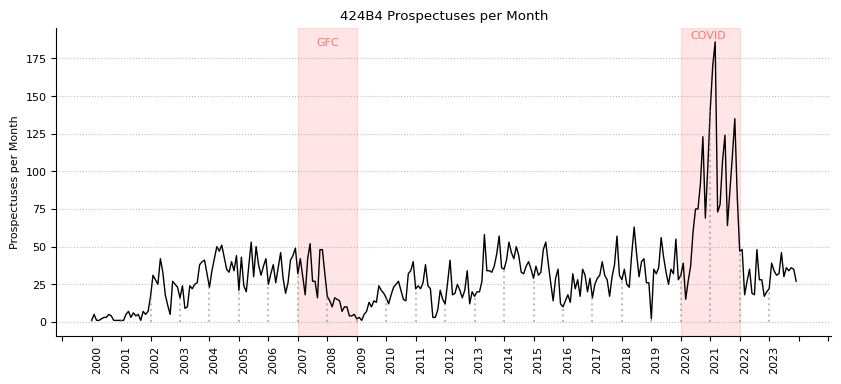

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

xticks = [
    f"{year}-{month}"
    for year, month in prospectuses_per_month[["year", "month"]].values
]

ax.plot(
    xticks,
    prospectuses_per_month["count"],
    color="black",
    linewidth=1,
)
ax.set_title("424B4 Prospectuses per Month"); ax.set_ylabel("Prospectuses per Month")
ax.set_xticks(xticks); ax.set_xticklabels(xticks, rotation=90, ha="left")
ax.xaxis.set_major_locator(mtick.MultipleLocator(12))
xlabels = [label.get_text() for label in ax.get_xticklabels()]
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: xlabels[pos][:4]))
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
# draw vertical lines for each first month of the year, dotted, transparency 0.5,
# with height of the y value for the respective month
for year, month in prospectuses_per_month[["year", "month"]].values:
    if month == 1:
        ax.vlines(
            f"{year}-{month}",
            ymin=0,
            ymax=prospectuses_per_month[
                (prospectuses_per_month["year"] == year)
                & (prospectuses_per_month["month"] == month)
            ]["count"].max(),
            linestyle=":",
            alpha=0.5,
            color="grey",
        )

ax.axvspan("2007-1", "2009-1", alpha=0.1, color="red", zorder=-100)
ax.axvspan("2020-1", "2022-1", alpha=0.1, color="red", zorder=-100)
ax.text("2008-1", ax.get_ylim()[1] - 10, "GFC", horizontalalignment="center", verticalalignment="center", color="red", alpha=0.5)
ax.text("2020-12", ax.get_ylim()[1] - 5, "COVID", horizontalalignment="center", verticalalignment="center", color="red",alpha=0.5)
plt.show()